In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths to the files we just created
ahsania_path = '../Results/amcgh_dosiomics.csv'
square_path = '../Results/square_dosiomics.csv'
output_path = '../Results/final_local_dosiomics.csv'

print("Loading datasets...")

# Load Ahsania
try:
    df_ahsania = pd.read_csv(ahsania_path)
    print(f"Ahsania Patients: {len(df_ahsania)}")
except:
    df_ahsania = pd.DataFrame()
    print("Warning: Ahsania file not found.")

# Load Square
try:
    df_square = pd.read_csv(square_path)
    print(f"Square Patients: {len(df_square)}")
except:
    df_square = pd.DataFrame()
    print("Warning: Square file not found.")

# Merge
df_final = pd.concat([df_ahsania, df_square], ignore_index=True)

# Save Master File
if not df_final.empty:
    df_final.to_csv(output_path, index=False)
    print(f"\nSUCCESS: Merged {len(df_final)} patients.")
    print(f"Master file saved to: {output_path}")
    display(df_final.head())
else:
    print("No data to merge.")

Loading datasets...
Ahsania Patients: 50
Square Patients: 121

SUCCESS: Merged 171 patients.
Master file saved to: ../Results/final_local_dosiomics.csv


,PatientID,Source,ROI_Name,ROI_Type,Mean_Dose_Gy,Max_Dose_Gy,Min_Dose_Gy,D95_Gy
0,1042new,Ahsania,GTV_3600/18,Target_GTV,37.425769,38.70,34.20,36.38
1,1083New,Ahsania,gtv t,Target_GTV,61.529368,64.52,57.24,58.71
2,1102 new,Ahsania,GTV_6000/30,Target_GTV,58.473025,61.29,55.97,56.83
3,1115new,Ahsania,ptv 6000/30,Target_PTV,60.780442,66.56,51.22,58.08
4,1127new,Ahsania,gtv t,Target_GTV,61.332940,63.35,59.35,59.96


In [2]:
# Calculate Summary Statistics by Hospital
if not df_final.empty:
    print("--- Dosiometric Comparison (Tumor Coverage) ---")
    
    # Group by Hospital (Source) and calculate Mean/Std for D95 (Target Coverage)
    summary = df_final.groupby('Source')['D95_Gy'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
    
    # Rename columns for professional look
    summary.columns = ['Patients', 'Mean D95 (Gy)', 'Std Dev', 'Min', 'Max']
    
    display(summary)
    
    # Save to CSV for Thesis Table
    summary.to_csv('../Results/table_dosiomics_summary.csv')

--- Dosiometric Comparison (Tumor Coverage) ---


,Patients,Mean D95 (Gy),Std Dev,Min,Max
Source,,,,,
Ahsania,50,54.61,11.79,0.68,63.01
Square,121,48.36,14.08,0.46,59.10


C:\Users\shuvo\AppData\Local\Temp\ipykernel_13532\3105785175.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


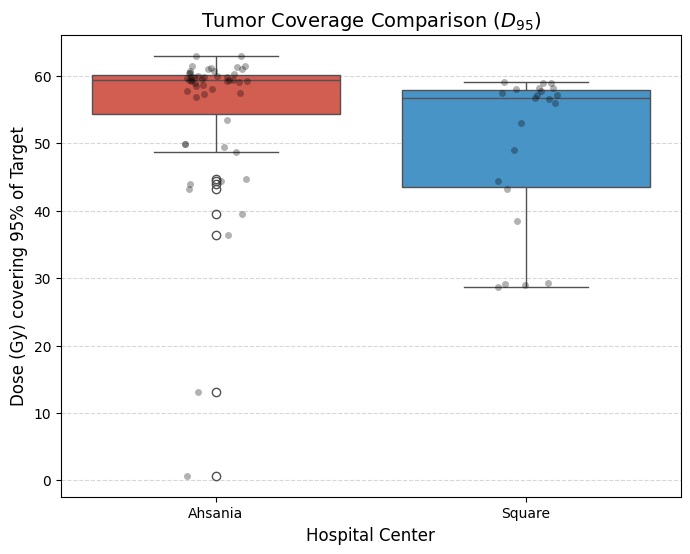

Plot saved to ../Results/Figure_Dosiomics_Comparison.png


In [ ]:
# if not df_final.empty:
#     plt.figure(figsize=(8, 6))
    
#     # Boxplot of D95 (Dose covering 95% of Tumor)
#     sns.boxplot(
#         data=df_final, 
#         x='Source', 
#         y='D95_Gy', 
#         palette=['#e74c3c', '#3498db'] # Red for Ahsania, Blue for Square
#     )
    
#     # Add individual points (jitter) so we can see sample size difference
#     sns.stripplot(data=df_final, x='Source', y='D95_Gy', color='black', alpha=0.3, jitter=True)
    
#     plt.title('Tumor Coverage Comparison ($D_{95}$)', fontsize=14)
#     plt.ylabel('Dose (Gy) covering 95% of Target', fontsize=12)
#     plt.xlabel('Hospital Center', fontsize=12)
#     plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    
#     # Save Figure
#     plt.savefig('../Results/Figure_Dosiomics_Comparison.png', dpi=300)
#     plt.show()
    
#     print("Plot saved to ../Results/Figure_Dosiomics_Comparison.png")

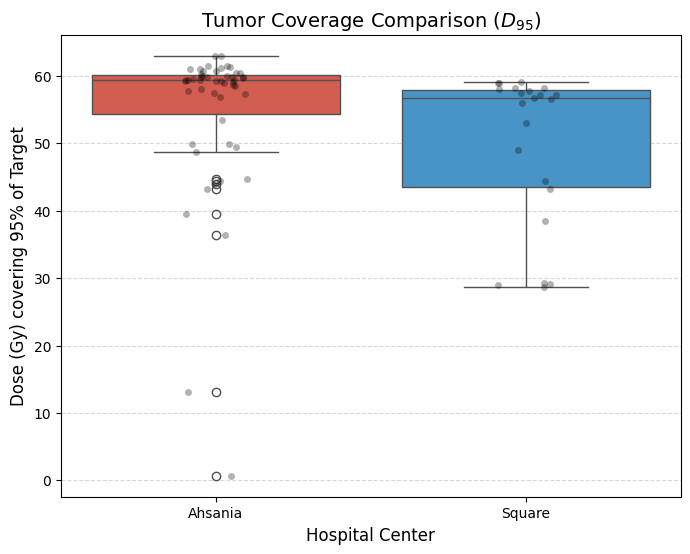

Plot saved to: d:\Thesis_Project\Results\Figure_Dosiomics_Comparison.png


In [ ]:
# if not df_final.empty:
#     plt.figure(figsize=(8, 6))
    
#     # Boxplot of D95 (Target Coverage)
#     # FIX: We mapped 'x' to 'hue' to fix the warning
#     sns.boxplot(
#         data=df_final, 
#         x='Source', 
#         y='D95_Gy', 
#         hue='Source', 
#         palette=['#e74c3c', '#3498db'], # Red vs Blue
#         legend=False
#     )
    
#     # Add individual points (jitter) so we can see the sample size difference
#     sns.stripplot(
#         data=df_final, 
#         x='Source', 
#         y='D95_Gy', 
#         color='black', 
#         alpha=0.3, 
#         jitter=True,
#         legend=False
#     )
    
#     plt.title('Tumor Coverage Comparison ($D_{95}$)', fontsize=14)
#     plt.ylabel('Dose (Gy) covering 95% of Target', fontsize=12)
#     plt.xlabel('Hospital Center', fontsize=12)
#     plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    
#     # Save Figure
#     output_fig = '../Results/Figure_Dosiomics_Comparison.png'
#     plt.savefig(output_fig, dpi=300)
#     plt.show()
    
#     print(f"Plot saved to: {os.path.abspath(output_fig)}")
# else:
#     print("DataFrame is empty. Cannot plot.")

In [3]:
import plotly.express as px
import plotly.io as pio

# Set default template
pio.templates.default = "plotly_white"

if not df_final.empty:
    print("Generating Interactive Plotly Graph...")

    # Create Box Plot with underlying points (Jitter)
    fig = px.box(
        df_final, 
        x='Source', 
        y='D95_Gy', 
        color='Source',
        points='all',  # Shows all individual patient dots
        hover_data=['PatientID'], # Hover over a dot to see the Patient ID!
        color_discrete_map={'Ahsania': '#EF553B', 'Square': '#636EF2'}, # Modern Red/Blue
        title='<b>Tumor Coverage Comparison</b> (Target D95)',
        labels={'D95_Gy': 'Dose (Gy) covering 95% of Target', 'Source': 'Hospital'}
    )

    # Polish the layout
    fig.update_layout(
        width=800,
        height=600,
        showlegend=False,
        font=dict(size=14),
        yaxis=dict(showgrid=True, gridcolor='#eee'),
        title_x=0.5 # Center title
    )

    # Show the plot
    fig.show()

    # Save as HTML (interactive) and PNG (static)
    fig.write_html("../Results/Figure_Dosiomics_Interactive.html")
    # Note: To save as PNG, you might need 'kaleido'. If this fails, just use HTML.
    try:
        fig.write_image("../Results/Figure_Dosiomics_Comparison.png", scale=3)
        print("Plots saved to ../Results/")
    except:
        print("Saved HTML only. Install 'kaleido' for PNG export.")
else:
    print("No data to plot.")

Generating Interactive Plotly Graph...


Plots saved to ../Results/
